<a href="https://colab.research.google.com/github/xbanuelos/BI-Portfolio/blob/main/phase_01/project_01_order_funnel/order_funnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Order Funnel Analysis

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
order = pd.read_csv('/content/olist_orders_dataset.csv')

In [66]:
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [67]:
order.shape

(99441, 8)

In [68]:
order.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


In [69]:
order.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [70]:
order['order_status'] = order['order_status'].fillna('unkown')

In [71]:
order[order['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [72]:
funnel = pd.DataFrame({
    'stage': [
        'purchased',
        'approved',
        'delivered to carrier',
        'delivered to customer'
    ],
    'count': [
        order['order_purchase_timestamp'].notna().sum(),
        order['order_approved_at'].notna().sum(),
        order['order_delivered_carrier_date'].notna().sum(),
        order['order_delivered_customer_date'].notna().sum()
    ]
})

funnel['conversion_rate'] = (
    funnel['count'] / funnel['count'].shift(1) * 100
).round(2)

funnel['conversion_rate'].iloc[0] = 100.0

funnel['drop_off'] = (funnel['count'].shift(1) - funnel['count']).fillna(0)

print(funnel)

                   stage  count  conversion_rate  drop_off
0              purchased  99441           100.00       0.0
1               approved  99281            99.84     160.0
2   delivered to carrier  97658            98.37    1623.0
3  delivered to customer  96476            98.79    1182.0


/tmp/ipykernel_30043/3219512120.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  funnel['conversion_rate'].iloc[0] = 100.0
/tmp/ipykernel_30043/3219512120.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

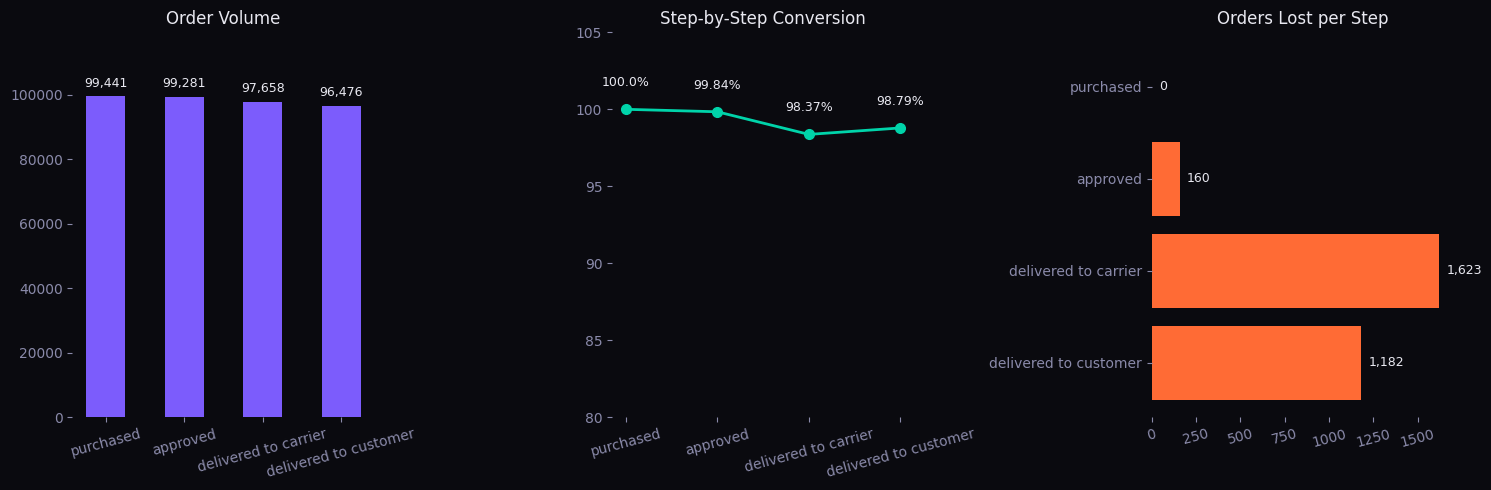

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0a0a0f')

# ---- CHART 1: Count ----
ax1 = axes[0]
bars = ax1.bar(funnel['stage'], funnel['count'], color='#7c5cfc', width=0.5)
ax1.bar_label(bars, labels=[f'{c:,}' for c in funnel['count']],
              padding=5, color='#e8e8f0', fontsize=9)
ax1.set_title('Order Volume', color='#e8e8f0')
ax1.set_ylim(0, funnel['count'].max() * 1.2)

# ---- CHART 2: Conversion rate ----
ax2 = axes[1]
ax2.plot(funnel['stage'], funnel['conversion_rate'],
         color='#00d4aa', marker='o', linewidth=2, markersize=7)
for i, (stage, val) in enumerate(zip(funnel['stage'], funnel['conversion_rate'])):
    ax2.text(i, val + 1.5, f'{val}%', ha='center', color='#e8e8f0', fontsize=9)
ax2.set_title('Step-by-Step Conversion', color='#e8e8f0')
ax2.set_ylim(80, 105)

# ---- CHART 3: Drop off ----
ax3 = axes[2]
bars3 = ax3.barh(funnel['stage'], funnel['drop_off'], color='#ff6b35')
ax3.bar_label(bars3, labels=[f'{int(d):,}' for d in funnel['drop_off']],
              padding=5, color='#e8e8f0', fontsize=9)
ax3.set_title('Orders Lost per Step', color='#e8e8f0')
ax3.invert_yaxis()

# ---- Estilo compartido ----
for ax in axes:
    ax.set_facecolor('#0a0a0f')
    ax.tick_params(colors='#8a8aaa')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('order_funnel_3charts.png', dpi=150)
plt.show()

## Insight 1
El paso de "appoved" -> "delivered to carrier" pierde 1,623 órdenes. La posible causa del problema está en la logística, no en la aprobación de pagos.